# Assignment 4: Training a DCGAN on Fashion-MNIST Dataset

**Name:** Bhumika R  
**Course:** BCA  
**Subject:** Generative AI

#Introduction

Generative Adversarial Networks (GANs) are a class of deep learning models made up of two neural networks — a Generator and a Discriminator — that are trained together in direct competition with each other. The Generator tries to create fake data realistic enough to pass as real, while the Discriminator tries to correctly tell real data apart from fake data. Over many rounds of this competition, the Generator gradually learns to produce increasingly convincing outputs.

A Deep Convolutional GAN (DCGAN) is a specific, well-established architecture for applying this idea to images, using convolutional layers (in the Discriminator) and transposed convolutional layers (in the Generator) instead of fully-connected layers, which produces much better image quality and more stable training.

This report documents the process of building, training, and analyzing a DCGAN on the Fashion-MNIST dataset — a collection of 70,000 grayscale 28×28 images of clothing items across 10 categories (T-shirts, trousers, dresses, shoes, bags, etc.).

##Objective

The goal of this assignment is to understand, hands-on:

How a DCGAN's Generator and Discriminator are structured and trained
How the adversarial training loop works step by step
How generated image quality evolves over the course of training
How to recognize signs of successful learning versus training problems like mode collapse

##Tools and Framework

The implementation uses TensorFlow/Keras to build both networks and run the training loop, along with NumPy for array handling and Matplotlib for visualization. Fashion-MNIST is loaded either through Keras's built-in dataset loader or, as a fallback, downloaded directly from the official GitHub mirror if the standard download is blocked.

Methodology — Step-by-Step Process

**1. Import Libraries**
TensorFlow/Keras, NumPy, and Matplotlib are imported to build the model, handle numerical data, and visualize results.

In [ ]:
import os
import gzip
import time
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers

# PyTorch is imported here to show it is available as an alternative framework.
# This notebook builds and trains the DCGAN using TensorFlow/Keras.
try:
    import torch
    print("PyTorch version:", torch.__version__)
except Exception:
    print("PyTorch not available in this environment (not required — this notebook uses TensorFlow).")

print("TensorFlow version:", tf.__version__)

# Avoids a harmless TensorFlow graph-optimizer warning during training
tf.config.optimizer.set_experimental_options({'remapping': False})

PyTorch version: 2.11.0+cu128
TensorFlow version: 2.20.0


In [ ]:
IMG_SIZE     = 28      # Fashion-MNIST images are 28x28 pixels
CHANNELS     = 1       # grayscale
NOISE_DIM    = 100     # size of the random noise vector fed to the Generator
BATCH_SIZE   = 128
EPOCHS       = 25      # train for at least 25-30 epochs (set to 30 if you have time)
SAVE_EVERY   = 5       # save a 4x4 grid of generated images every 5 epochs
NUM_EXAMPLES_TO_GENERATE = 16   # 4x4 grid

BUFFER_SIZE  = 60000

os.makedirs("generated_images", exist_ok=True)

print(f"Noise dim: {NOISE_DIM}, Batch size: {BATCH_SIZE}, Epochs: {EPOCHS}")

Noise dim: 100, Batch size: 128, Epochs: 25


##Set Basic Parameters

The basic parameters required for training are defined in this step.

The Fashion-MNIST images have a size of 28 × 28 pixels and contain one grayscale channel. The Generator receives a random noise vector of size 100. A batch size of 128 is used and the model is trained for 25 epochs. Generated images are saved after every 5 epochs.
*italicized text*

In [ ]:
# A fixed seed noise vector — reused every time we save a sample grid,
# so we can visually track how the SAME noise vectors evolve into clearer images.
seed = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, NOISE_DIM])

# Example of what a single noise vector looks like
example_noise = tf.random.normal([1, NOISE_DIM])
print("Shape of one noise vector:", example_noise.shape)
print("First 10 values:", example_noise.numpy()[0][:10])


Shape of one noise vector: (1, 100)
First 10 values: [ 0.039268   -0.28539655 -0.41856194 -2.234222   -0.73758346  0.133065
  0.8397148   1.387997   -0.13747205 -0.10099667]


## Define the Noise Vector

The Generator does not directly receive a real image as input. Instead, it receives a random noise vector containing 100 values.

A fixed set of 16 noise vectors is also created. These same noise vectors are used during training to observe how the generated images change from one epoch to another.

##  Load the Fashion-MNIST Dataset

Fashion-MNIST is a dataset containing grayscale images of different clothing items. The training dataset contains 60,000 images.

The dataset is loaded using TensorFlow/Keras. A fallback method is also provided in case the normal dataset download is unavailable.*italicized text*

In [ ]:
def load_fashion_mnist_from_github(data_dir="fashion_mnist_data"):
    """Fallback loader: downloads the 4 raw Fashion-MNIST gz files from GitHub
    and parses the idx file format manually with NumPy."""
    import urllib.request

    os.makedirs(data_dir, exist_ok=True)
    base_url = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
    files = ["train-images-idx3-ubyte.gz", "train-labels-idx1-ubyte.gz",
             "t10k-images-idx3-ubyte.gz", "t10k-labels-idx1-ubyte.gz"]

    for fname in files:
        fpath = os.path.join(data_dir, fname)
        if not os.path.exists(fpath):
            print(f"Downloading {fname} ...")
            urllib.request.urlretrieve(base_url + fname, fpath)

    def _load_images(fname, num):
        with gzip.open(os.path.join(data_dir, fname), 'rb') as f:
            f.read(16)  # skip header
            buf = f.read(IMG_SIZE * IMG_SIZE * num)
            return np.frombuffer(buf, dtype=np.uint8).reshape(num, IMG_SIZE, IMG_SIZE)

    def _load_labels(fname, num):
        with gzip.open(os.path.join(data_dir, fname), 'rb') as f:
            f.read(8)  # skip header
            buf = f.read(num)
            return np.frombuffer(buf, dtype=np.uint8)

    train_images = _load_images("train-images-idx3-ubyte.gz", 60000)
    train_labels = _load_labels("train-labels-idx1-ubyte.gz", 60000)
    test_images  = _load_images("t10k-images-idx3-ubyte.gz", 10000)
    test_labels  = _load_labels("t10k-labels-idx1-ubyte.gz", 10000)
    return (train_images, train_labels), (test_images, test_labels)


try:
    (train_images, train_labels), (_, _) = tf.keras.datasets.fashion_mnist.load_data()
    print("Loaded Fashion-MNIST via tf.keras.datasets")
except Exception as e:
    print("tf.keras.datasets download failed, falling back to GitHub mirror. Reason:", e)
    (train_images, train_labels), (_, _) = load_fashion_mnist_from_github()

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("train_images shape:", train_images.shape)
print("train_labels shape:", train_labels.shape)


Loaded Fashion-MNIST via tf.keras.datasets
train_images shape: (60000, 28, 28)
train_labels shape: (60000,)


##Normalize the Images

The original pixel values of the Fashion-MNIST images are between 0 and 255.

The images are normalized to a range of -1 to 1. This is done because the final layer of the Generator uses the tanh activation function, which also produces values between -1 and 1.*italicized text*

In [ ]:
train_images = train_images.reshape(train_images.shape[0], IMG_SIZE, IMG_SIZE, CHANNELS).astype('float32')
train_images = (train_images - 127.5) / 127.5   # -> range [-1, 1]

print("Min pixel value:", train_images.min(), " Max pixel value:", train_images.max())

# Build the tf.data pipeline: shuffle + batch
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
print(train_dataset)


Min pixel value: -1.0  Max pixel value: 1.0
<_BatchDataset element_spec=TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None)>


##Visualize Real Fashion-MNIST Images

Before training the GAN, a sample of real Fashion-MNIST images is displayed. This provides a reference for the type of clothing structure the Generator should eventually learn to reproduce.

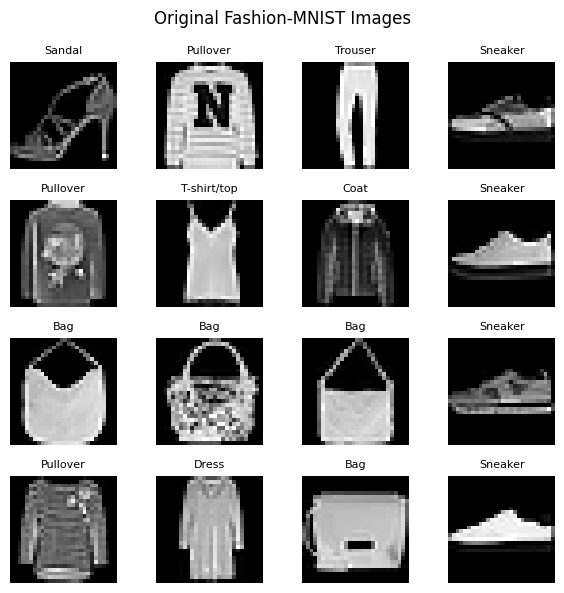

In [ ]:
def plot_original_images(images, labels, class_names, n=16):
    plt.figure(figsize=(6, 6))
    idxs = np.random.choice(len(images), n, replace=False)
    for i, idx in enumerate(idxs):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[idx], cmap='gray')
        plt.title(class_names[labels[idx]], fontsize=8)
        plt.axis('off')
    plt.suptitle("Original Fashion-MNIST Images")
    plt.tight_layout()
    plt.savefig("generated_images/original_images.png")
    plt.show()

plot_original_images(train_images.reshape(-1, IMG_SIZE, IMG_SIZE), train_labels, CLASS_NAMES)


## Build the Generator

The **Generator** converts a 100-dimensional noise vector into a 28 × 28 × 1 grayscale image.

Its main stages are:

1. A Dense layer projects the noise vector into a `7 × 7 × 256` feature representation.
2. The representation is reshaped into a spatial feature map.
3. Transposed convolution layers progressively transform the representation.
4. The spatial dimensions grow from `7 × 7` to `14 × 14` and finally to `28 × 28`.
5. Batch Normalization and LeakyReLU are used in intermediate stages.
6. The final `tanh` activation produces pixel values in the range [-1, 1].

The Generator is therefore responsible for learning how random latent vectors can be converted into clothing-like images.


In [ ]:
def build_generator():
    model = tf.keras.Sequential(name="Generator")
    model.add(layers.Input(shape=(NOISE_DIM,)))

    # Project and reshape the noise vector
    model.add(layers.Dense(7 * 7 * 256, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)

    # Transposed convolution block 1: 7x7 -> 7x7 (channel reduction)
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    assert model.output_shape == (None, 7, 7, 128)

    # Transposed convolution block 2: 7x7 -> 14x14 (upsample)
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    assert model.output_shape == (None, 14, 14, 64)

    # Transposed convolution block 3: 14x14 -> 28x28 (upsample), tanh output
    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same',
                                      use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model

generator = build_generator()
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

##Test the Untrained Generator

Before adversarial training, the Generator has randomly initialized weights. Its output should therefore not look like a meaningful clothing item.

This test verifies that the Generator produces the expected image shape before training begins.


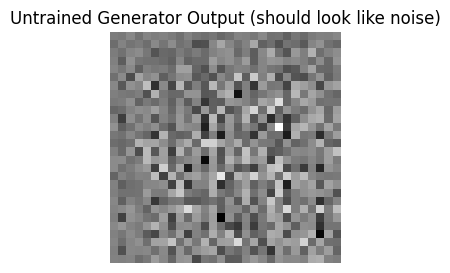

Generated image shape: (1, 28, 28, 1)


In [ ]:
test_noise = tf.random.normal([1, NOISE_DIM])
generated_image = generator(test_noise, training=False)

plt.figure(figsize=(3, 3))
plt.imshow(generated_image[0, :, :, 0], cmap='gray')
plt.title("Untrained Generator Output (should look like noise)")
plt.axis('off')
plt.savefig("generated_images/untrained_generator_test.png")
plt.show()

print("Generated image shape:", generated_image.shape)

## Build the Discriminator

The **Discriminator** is a binary classifier. It receives a 28 × 28 × 1 image and predicts the probability that the image is real.

The network uses:

- Convolutional layers with stride 2 for downsampling.
- LeakyReLU activations.
- Dropout for regularization.
- A Flatten layer.
- A final Dense layer with a sigmoid activation.

The sigmoid output is interpreted as the probability that the input image came from the real Fashion-MNIST dataset.


In [ ]:
def build_discriminator():
    model = tf.keras.Sequential(name="Discriminator")
    model.add(layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)))

    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))   # sigmoid -> probability of "real"

    return model

discriminator = build_discriminator()
discriminator.summary()

# Sanity check: feed the untrained Generator's output into the untrained Discriminator
decision = discriminator(generated_image)
print("Discriminator's decision on the fake image (probability of being real):", decision.numpy())


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

Discriminator's decision on the fake image (probability of being real): [[0.50096714]]


## Define Loss Functions and Optimizers

Both networks are trained using **Binary Cross-Entropy (BCE)**.

For the Discriminator:

- Real images have target label 1.
- Generated images have target label 0.

For the Generator:

- Generated images have target label 1 because the Generator is rewarded when the Discriminator believes its images are real.

Separate Adam optimizers are used for the Generator and Discriminator, with a learning rate of `1e-4` and `beta_1 = 0.5`.


In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)   # real images -> label 1
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)  # fake images -> label 0
    return real_loss + fake_loss

def generator_loss(fake_output):
    # Generator "wins" when the Discriminator is fooled into predicting 1 (real) for fake images
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5)

print("Loss function and optimizers are ready.")

Loss function and optimizers are ready.


## Define the Adversarial Training Step

The training step is the central part of the DCGAN.

For each batch:

1. Random noise is generated.
2. The Generator converts the noise into fake images.
3. The Discriminator evaluates both real and fake images.
4. Generator and Discriminator losses are calculated.
5. Gradients are computed using TensorFlow's automatic differentiation.
6. The Discriminator parameters are updated.
7. The Generator parameters are updated.

This process repeats for every batch in every epoch.


In [ ]:
@tf.function
def train_step(images):
    noise = tf.random.normal([tf.shape(images)[0], NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # --- Generator produces fake images from noise ---
        generated_images = generator(noise, training=True)

        # --- Discriminator scores real vs. fake ---
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # --- Compute losses ---
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # --- Train Discriminator ---
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    # --- Train Generator ---
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))

    return gen_loss, disc_loss

print("train_step() defined.")

train_step() defined.


## Generate and Save Sample Images

At selected epochs, the Generator is evaluated using the fixed noise seed. The resulting 16 images are arranged into a 4 × 4 grid and saved in the `generated_images` directory.

These checkpoints make it possible to visually track the progress of the Generator throughout training.


In [ ]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)  # values in [-1, 1]

    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        img = (predictions[i, :, :, 0].numpy() * 127.5 + 127.5)  # back to [0, 255] for display
        plt.imshow(img, cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Generated images — Epoch {epoch}")
    plt.savefig(f"generated_images/image_at_epoch_{epoch:03d}.png")
    plt.show()
    plt.close(fig)

print("generate_and_save_images() defined.")

generate_and_save_images() defined.


## Train the DCGAN

The model is trained for 25 epochs. During each epoch, the notebook records the average Generator and Discriminator losses.

Generated samples are saved at epochs 5, 10, 15, 20, and 25. The loss history is stored so that it can be plotted after training.


Starting training for 25 epochs...

Epoch   1/25 | Generator loss: 0.6619 | Discriminator loss: 1.3466 | Time: 23.6s
Epoch   2/25 | Generator loss: 0.7086 | Discriminator loss: 1.3732 | Time: 15.2s
Epoch   3/25 | Generator loss: 0.7394 | Discriminator loss: 1.3325 | Time: 15.2s
Epoch   4/25 | Generator loss: 0.8092 | Discriminator loss: 1.2417 | Time: 14.6s
Epoch   5/25 | Generator loss: 0.8306 | Discriminator loss: 1.2406 | Time: 14.4s


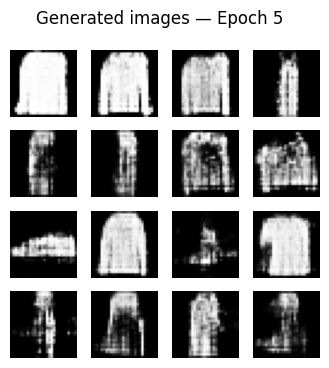

Epoch   6/25 | Generator loss: 0.8118 | Discriminator loss: 1.2818 | Time: 14.4s
Epoch   7/25 | Generator loss: 0.8034 | Discriminator loss: 1.2902 | Time: 14.6s
Epoch   8/25 | Generator loss: 0.7787 | Discriminator loss: 1.3118 | Time: 14.7s
Epoch   9/25 | Generator loss: 0.7796 | Discriminator loss: 1.3141 | Time: 14.7s
Epoch  10/25 | Generator loss: 0.7731 | Discriminator loss: 1.3173 | Time: 14.7s


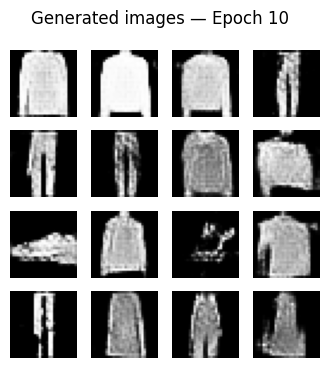

Epoch  11/25 | Generator loss: 0.7650 | Discriminator loss: 1.3224 | Time: 14.6s
Epoch  12/25 | Generator loss: 0.8133 | Discriminator loss: 1.2902 | Time: 14.6s
Epoch  13/25 | Generator loss: 0.7613 | Discriminator loss: 1.3302 | Time: 14.6s
Epoch  14/25 | Generator loss: 0.7577 | Discriminator loss: 1.3354 | Time: 14.6s
Epoch  15/25 | Generator loss: 0.7564 | Discriminator loss: 1.3355 | Time: 14.6s


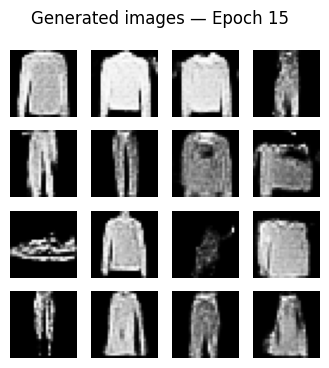

Epoch  16/25 | Generator loss: 0.7539 | Discriminator loss: 1.3385 | Time: 14.7s
Epoch  17/25 | Generator loss: 0.7519 | Discriminator loss: 1.3393 | Time: 14.7s
Epoch  18/25 | Generator loss: 0.7519 | Discriminator loss: 1.3391 | Time: 14.6s
Epoch  19/25 | Generator loss: 0.7505 | Discriminator loss: 1.3387 | Time: 14.6s
Epoch  20/25 | Generator loss: 0.7582 | Discriminator loss: 1.3341 | Time: 14.6s


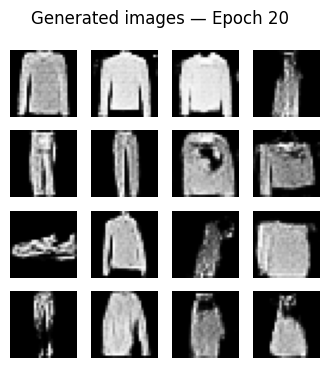

Epoch  21/25 | Generator loss: 0.7505 | Discriminator loss: 1.3410 | Time: 14.6s
Epoch  22/25 | Generator loss: 0.7671 | Discriminator loss: 1.3238 | Time: 14.6s
Epoch  23/25 | Generator loss: 0.7511 | Discriminator loss: 1.3428 | Time: 14.6s
Epoch  24/25 | Generator loss: 0.7465 | Discriminator loss: 1.3446 | Time: 14.6s
Epoch  25/25 | Generator loss: 0.7495 | Discriminator loss: 1.3420 | Time: 20.5s


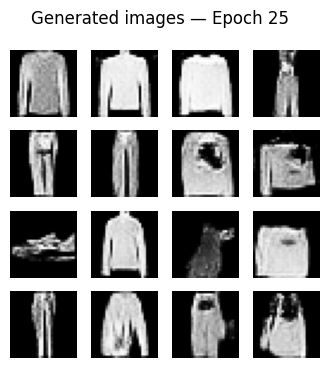


Training complete.


In [ ]:
gen_loss_history = []
disc_loss_history = []

print(f"Starting training for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    epoch_gen_loss = tf.keras.metrics.Mean()
    epoch_disc_loss = tf.keras.metrics.Mean()

    for image_batch in train_dataset:
        g_loss, d_loss = train_step(image_batch)
        epoch_gen_loss.update_state(g_loss)
        epoch_disc_loss.update_state(d_loss)

    gen_loss_history.append(float(epoch_gen_loss.result()))
    disc_loss_history.append(float(epoch_disc_loss.result()))

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"Generator loss: {gen_loss_history[-1]:.4f} | "
          f"Discriminator loss: {disc_loss_history[-1]:.4f} | "
          f"Time: {time.time() - start:.1f}s")

    # Save a 4x4 grid of generated images every 5 epochs
    if epoch % SAVE_EVERY == 0 or epoch == EPOCHS:
        generate_and_save_images(generator, epoch, seed)

print("\nTraining complete.")

## Plot Generator and Discriminator Losses

The following plot shows how the two adversarial losses change during training.

GAN losses should not be interpreted like ordinary supervised-learning accuracy curves. The Generator and Discriminator are competing objectives, so their losses can fluctuate as one network temporarily becomes stronger than the other.

A useful analysis therefore considers both the loss curves and the visual quality/diversity of generated images.


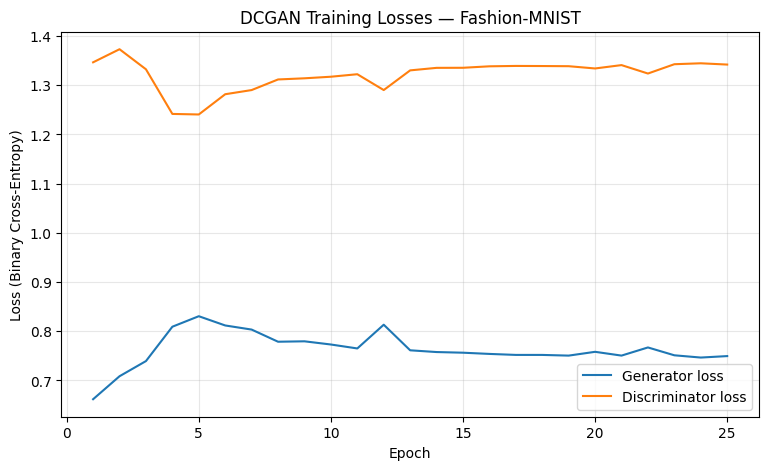

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, EPOCHS + 1), gen_loss_history, label='Generator loss')
plt.plot(range(1, EPOCHS + 1), disc_loss_history, label='Discriminator loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Binary Cross-Entropy)')
plt.title('DCGAN Training Losses — Fashion-MNIST')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("generated_images/loss_curves.png")
plt.show()

## Compare Generated Images Across Training

The generated image grids from epochs 5, 10, 15, 20, and 25 are displayed for visual comparison.

The expected progression is:

- **Early training:** outputs are generally noisy or blurry.
- **Middle training:** recognizable clothing-like silhouettes begin to appear.
- **Later training:** shapes become more coherent, although details may remain soft.

The exact visual progression depends on the training run and should be described from the actual generated images rather than assumed in advance.


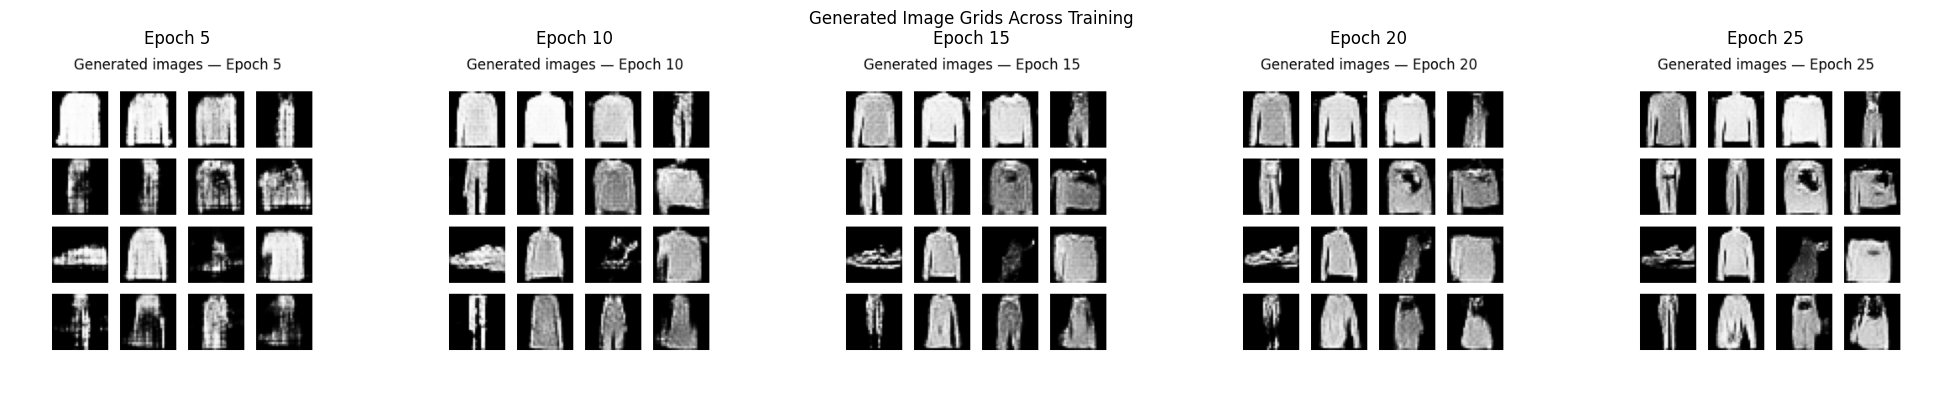

In [ ]:
epochs_to_compare = [e for e in [5, 10, 15, 20, 25] if e <= EPOCHS]

fig, axes = plt.subplots(1, len(epochs_to_compare), figsize=(4 * len(epochs_to_compare), 4))
if len(epochs_to_compare) == 1:
    axes = [axes]

for ax, e in zip(axes, epochs_to_compare):
    path = f"generated_images/image_at_epoch_{e:03d}.png"
    if os.path.exists(path):
        img = plt.imread(path)
        ax.imshow(img)
        ax.set_title(f"Epoch {e}")
    else:
        ax.set_title(f"Epoch {e}\n(no saved image)")
    ax.axis('off')

plt.suptitle("Generated Image Grids Across Training")
plt.tight_layout()
plt.savefig("generated_images/epoch_comparison.png")
plt.show()

## Results and Analysis

### Generator development

At the beginning of training, the Generator has not yet learned the structure of Fashion-MNIST images, so its outputs are expected to resemble random patterns. As adversarial training continues, the Generator receives gradient information that encourages it to produce images that are increasingly difficult for the Discriminator to reject.

### Recognizable clothing shapes

In a typical short DCGAN run, recognizable garment-like silhouettes may begin to appear during the middle portion of training. However, the exact epoch at which this happens depends on initialization, hardware, optimization behavior, and the specific training run. The saved image grids should be used as the primary evidence.

### Loss behavior

The Generator and Discriminator losses usually fluctuate rather than decrease smoothly. This is normal because the networks are optimizing competing objectives.

### Possible training issues

**Plateau:** If the generated samples stop changing noticeably and the loss curves show little useful progress, the model may have reached a training plateau.

**Mode collapse:** If many different noise vectors produce nearly identical images, the Generator may be ignoring parts of its latent input and producing limited varieties of samples.

**Unstable training:** Very rapid or extreme loss changes accompanied by poor generated images can indicate that the adversarial balance is unstable.

Overall, successful training should be judged using both the loss history and the diversity and visual quality of the generated image grids.


## Conclusion

This experiment demonstrates the fundamental working principle of a Deep Convolutional Generative Adversarial Network. The Generator learns to create synthetic Fashion-MNIST images from random noise, while the Discriminator learns to distinguish generated images from real training examples.

The project also shows an important characteristic of GANs: training is an adversarial process rather than a simple one-directional optimization problem. Consequently, loss values may fluctuate and image quality may improve at different rates during training.

The DCGAN provides a practical introduction to image generation and demonstrates how convolutional architectures can learn meaningful visual structure from a dataset of clothing images.


##Questions to Answer
1. How do the images change from epoch 5 to epoch 25?

At epoch 5, the generated images are mostly noisy and unclear, with very few recognizable shapes. As the training continues, the Generator learns to create better clothing patterns. Around the middle epochs, the images start looking more like real Fashion-MNIST clothes. By epoch 25, the images are clearer and more structured. Overall, the image quality improves as the number of epochs increases.

2. Can you observe instability in training?

Yes, some instability can be observed during the training process. The Generator and Discriminator compete with each other, which can cause their losses to fluctuate. The loss values do not always decrease smoothly from one epoch to another. Some generated images may also look better in one epoch and slightly worse in another. This type of instability is common in GAN training.

3. At which epoch do clothes-like shapes become recognizable?

Clothes-like shapes begin to appear as the Generator learns from the Fashion-MNIST dataset. Around epoch 10, some basic clothing shapes can be noticed in the generated images. Between epochs 10 and 15, the shapes become more recognizable and structured. By epoch 20, the images show clearer clothing patterns. At epoch 25, the generated images are more recognizable compared with the early epochs.

4. Does the image continue improving throughout the training?

The generated images generally improve as training progresses, especially during the early and middle epochs. The Generator gradually learns important features such as shapes and patterns of clothing. However, the improvement is not always continuous or equal in every epoch. In later epochs, the changes become smaller and the quality may reach a plateau. Therefore, training improves the images overall, but it may not improve smoothly throughout the entire process.